# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [108]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2
from sklearn.preprocessing import OneHotEncoder

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [109]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [110]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_1h.parquet")

In [111]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,1,residential,2,2,0.000000,1121.500000,6.430000,20.455000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01 00:00:00,482136,2,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01 00:00:00,482136,3,residential,7,7,15.000000,1244.142857,5.698571,19.598571,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01 00:00:00,482136,4,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01 00:00:00,482136,5,residential,2,2,0.000000,1338.500000,5.190000,17.780000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674515,2025-12-31 23:00:00,490895,73,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
674516,2025-12-31 23:00:00,490895,74,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
674517,2025-12-31 23:00:00,490895,75,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
674518,2025-12-31 23:00:00,490895,76,airport,20,20,162.692308,1574.900000,14.826000,37.737500,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 4.2.1 Data Information

In [112]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    674,520
Unique combinations (no time) :    674,520
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  674,520 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :    1,848
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :  308,314  (45.7%)
Non-zero-demand rows           :  366,206  (54.3%)


In [113]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,2,2,0.0,1121.500000,6.430000,20.455000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,0,0,0.0,0.000000,0.000000,0.000000,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,7,7,15.0,1244.142857,5.698571,19.598571,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,0,0,0.0,0.000000,0.000000,0.000000,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,2,2,0.0,1338.500000,5.190000,17.780000,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 4.2.2 Model Configurations

In [114]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "mse"  # "mse" | "mae" | "poisson_nll" (Poisson NLL on raw counts, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}

HP_LR_CANDIDATES = []


## 4.2.3 Model Definition

In [115]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") != "poisson_nll":
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(λ), consumed by PoissonNLLLoss(log_input=True)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None):
    set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    else:
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # "poisson_nll": model outputs log-rate; exp() applied internally

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=_lr)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, yb in pbar:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    model.load_state_dict(best_state)
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [116]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  device='cpu',
                  lr_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{{'#':>4}}  {{'lr':>8}}  {{'mean val':>10}}  {{'std':>8}}")
    print('-' * 35)

    results = []
    for i, (lr,) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                seed=seed, device=device, verbose=False,
                lr=lr, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌──────────────────────┬──────────────────────────────┬─────────────┐
│ pickup_community_area│  is_weekend, temp, rain, ...  │ trip_count  │
│         8            │  0,  12.3,  0.0,  ...        │      5      │
└──────────┬───────────┴───────────────┬───────────────┴──────┬──────┘
           │                           │                       │
           ▼                           ▼                       ▼
     OneHotEncoder               StandardScaler            target y
  area_8=1, rest=0           [0.0, -0.3, ...]               5.0
  (n_ca binary columns)       (n_num scaled columns)
           │                           │
           └──────────────┬────────────┘
                          ▼
                    np.concatenate
         [0, ..., 1, ..., 0,  0.0, -0.3, ...]
               (n_ca + n_num total dims)
                          │
                          ▼
              ┌─────────────────────┐
              │  Linear(dim → 64)   │
              │  ReLU               │
              │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
              │  ReLU               │
              │  Linear(64 → 1)     │
              │  Softplus           │  ← keeps output ≥ 0 (trip count)
              └─────────────────────┘
                          │
                          ▼
                   ŷ  (predicted trip count)
```

Community area identity is encoded as a one-hot vector (fit on training data only).
The network learns a separate weight for each area directly in the first linear layer.

## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [117]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :   472,164 rows
Val   :   101,178 rows
Test  :   101,178 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Community Area Encoding

Community area identity is encoded using **one-hot encoding** (fit on the training
set only). Each of the `n_ca` unique areas becomes a binary indicator column,
concatenated with the scaled numeric features before the first linear layer.

This replaces the learnable embedding used in the hexagon notebooks. With only
~77 areas the one-hot representation is compact enough to be practical, and it
has the advantage of being directly interpretable — each area gets its own
explicit weight vector in the first layer.

In [118]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "temperature_2m", "rain", "poi_density_total_per_km2",
    "universities_per_km2", "cloud_cover", "is_day", "snowfall"
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# One-hot encode community area (fit on train only to avoid leakage)
ohe          = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ca_train_ohe = ohe.fit_transform(train_data[['pickup_community_area']])
ca_val_ohe   = ohe.transform(val_data[['pickup_community_area']])
ca_test_ohe  = ohe.transform(test_data[['pickup_community_area']])

scaler      = StandardScaler()
X_train_num = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val_num   = scaler.transform(val_data[FEATURE_COLS].values)
X_test_num  = scaler.transform(test_data[FEATURE_COLS].values)

X_train = np.concatenate([X_train_num, ca_train_ohe], axis=1)
X_val   = np.concatenate([X_val_num,   ca_val_ohe],   axis=1)
X_test  = np.concatenate([X_test_num,  ca_test_ohe],  axis=1)

IS_POISSON = (getattr(config, "LOSS", "mse") == "poisson_nll")

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (Poisson NLL)' if IS_POISSON else 'log1p'}")

n_ca = ca_train_ohe.shape[1]
print(f"Community area one-hot columns : {n_ca}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Numeric features (22): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'apparent_temperature', 'precipitation', 'wind_speed_10m', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : log1p
Community area one-hot columns : 77

X_train : (472164, 99)   y_train : (472164,)
X_val   : (101178, 99)     y_val   : (101178,)
X_test  : (101178, 99)    y_test  : (101178,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

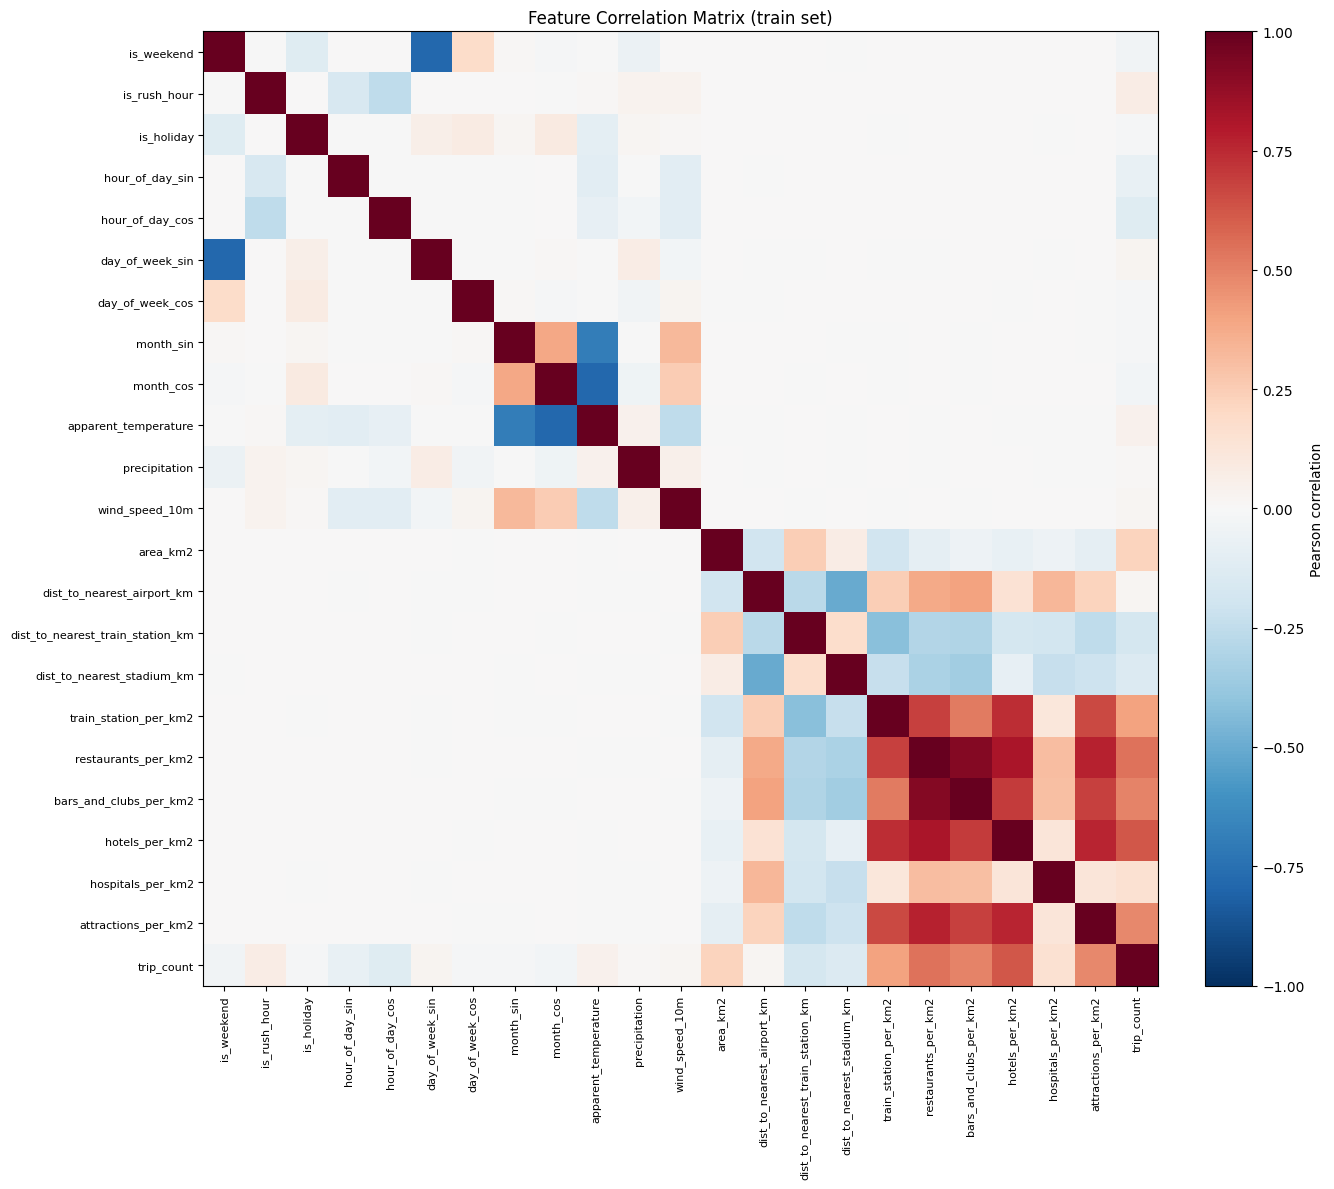

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820


In [119]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [121]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.412026         1.212591             0.004813
                 hour_of_day_cos       0.161719         0.371911             0.002676
                 hour_of_day_sin       0.127756         0.277614             0.003575
      dist_to_nearest_airport_km       0.073904         0.111444             0.000675
                        area_km2       0.084288         0.109317             0.000741
                 day_of_week_sin       0.027957         0.048289             0.000894
      dist_to_nearest_stadium_km       0.021211         0.034086             0.000150
                      is_weekend       0.018415         0.023741             0.000525
                    is_rush_hour       0.006997         0.021910             0.000455
                       month_cos       0.011908         0.021310             0.000391
                 day_of_week_cos       0.006058       

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [122]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296

Historical mean (area × hour)        R²=0.8174  MAE=3.4796  RMSE=13.9161  NRMSE=1.8482
Ridge regression                     R²=0.5571  MAE=4.7163  RMSE=21.6728  NRMSE=2.8783


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [123]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width)
x_dummy   = torch.zeros(1, input_dim)
summary(viz_model, input_data=x_dummy, col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 99]                   [1]                       --
├─Sequential: 1-1                        [1, 99]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 99]                   [1, 64]                   6,400
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 10,625
Trainable params: 10,625
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 99]                   [1]                       --
├─Sequential: 1-1                        [1, 99]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 99]                   [1, 64]                   6,400
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 10,625
Trainable params: 10,625
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

In [124]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.9084  val_loss: 0.5976 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.4643  val_loss: 0.3948 ✓
Epoch   3/200


...

  loss: 0.1657  val_loss: 0.1970  (no improvement 8/10)
Epoch  73/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1655  val_loss: 0.1977  (no improvement 9/10)
Epoch  74/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1653  val_loss: 0.1982  (no improvement 10/10)

  ↳ early stop at epoch 74  best_val=0.1959  best_train=0.1666

baseline  train: 0.1666 ± 0.0000  val: 0.1959 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [125]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, baseline_models):
    model.eval()

    print(f"  seed={seed} layer weight stats:")
    for name, param in model.named_parameters():
        if "weight" in name:
            w = param.detach().cpu().numpy()
            print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                  f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : baseline_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, baseline_train_losses, baseline_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(baseline_train_losses):>8.4f}  {np.mean(baseline_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0 layer weight stats:
    net.0.weight    shape=(64, 99)      max|w|=0.7792  mean|w|=0.1347  norm=13.6756
    net.2.weight    shape=(64, 64)      max|w|=0.9912  mean|w|=0.1463  norm=11.7451
    net.4.weight    shape=(1, 64)       max|w|=0.8982  mean|w|=0.2200  norm=2.0868
  seed=0  R²=0.7686  MAE=3.5039  NRMSE=2.0804  | log  R²=0.8410  MAE=0.3474  NRMSE=0.5958  | zeros 38,063/51,971  false=8,221  | pred min=0.0 max=293.7

--- original scale ---
Baseline  R²    : 0.7686 ± 0.0000
Baseline  MAE   : 3.5039 ± 0.0000
Baseline  RMSE  : 15.6649 ± 0.0000
Baseline  NRMSE : 2.0804 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.8410 ± 0.0000
Baseline  MAE   : 0.3474 ± 0.0000
Baseline  RMSE  : 0.4621 ± 0.0000
Baseline  NRMSE : 0.5958 ± 0.0000

--- zero-demand ---
Baseline  Correct-zero : 38063.0 ± 0.0  (out of 51,971)
Baseline  False-zero   : 8221.0 ± 0.0  (predicted 0 when demand > 0)

Tuned Baseline  R²=0.9313 ± 0.0020  MAE=4.4563 ± 0.0101  NRMSE=0.7787 ± 0.0113


In [126]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:40:05 baseline         2     64        0.00005        1024     0  0.195946              51971     7.529611 0.768623 3.503918 15.664898 2.080439 0.840956 0.347359  0.462112   0.595778                    NaN                        NaN  mse       38063.0      8221.0  0.001192 293.716156


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [127]:
# HP search candidates — Baseline (2 layers × 64 units)
# Narrow range first; widen if best LR sits at an edge
# LR_CANDIDATES_BASELINE = [2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4] # best LR = 1e-4
# LR_CANDIDATES_BASELINE = [1e-4, 2e-4, 3e-4, 4e-4] # best LR = 4e-4
# LR_CANDIDATES_BASELINE = [4e-4, 5e-4, 6e-4, 7e-4] # best LR = 7e-4
# LR_CANDIDATES_BASELINE = [8e-4, 9e-4, 1e-3, 2e-3, 3e-3, 4e-3] # best LR = 4e-3
# LR_CANDIDATES_BASELINE = [3e-3, 4e-3, 5e-3, 6e-3, 7e-3] # best LR =6e-3
LR_CANDIDATES_BASELINE = [3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3, 1e-2, 2e-2] # best LR = 9e-3


In [128]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
)

HP Search — baseline
9 combos × 1 seed(s) = 9 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     3e-03      0.1918    0.0000
   2     4e-03      0.1903    0.0000
   3     5e-03      0.1896    0.0000
   4     6e-03      0.1878    0.0000
   5     7e-03      0.1884    0.0000
   6     8e-03      0.1908    0.0000
   7     9e-03      0.1863    0.0000
   8     1e-02      0.1887    0.0000
   9     2e-02      0.1876    0.0000

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.009       0.186343           0.0
0.020       0.187624           0.0
0.006       0.187762           0.0
0.007       0.188407           0.0
0.010       0.188691           0.0

BEST_HP[baseline] = {'lr': 0.009}


{'lr': 0.009}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [129]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.009}

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1988  val_loss: 0.2137 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1714  val_loss: 0.1947 ✓
Epoch   3/200


...

  loss: 0.1596  val_loss: 0.2222  (no improvement 8/10)
Epoch  19/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1596  val_loss: 0.1994  (no improvement 9/10)
Epoch  20/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1594  val_loss: 0.1994  (no improvement 10/10)

  ↳ early stop at epoch 20  best_val=0.1863  best_train=0.1621

baseline  train: 0.1621 ± 0.0000  val: 0.1863 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [130]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "baseline_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_BASELINE]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : mean_actual,
        "r2"                : r2,
        "mae"               : mae,
        "rmse"              : rmse,
        "nrmse"             : nrmse,
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Baseline  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Baseline  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_train_losses, tuned_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_train_losses):>8.4f}  {np.mean(tuned_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.8226  MAE=3.2001  NRMSE=1.8217  | log  R²=0.8433  MAE=0.3451  NRMSE=0.5913  | zeros 37,802/51,971  false=7,979  | pred min=0.0 max=336.1

--- original scale ---
Tuned Baseline  R²    : 0.8226 ± 0.0000
Tuned Baseline  MAE   : 3.2001 ± 0.0000
Tuned Baseline  RMSE  : 13.7168 ± 0.0000
Tuned Baseline  NRMSE : 1.8217 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.8433 ± 0.0000
Tuned Baseline  MAE   : 0.3451 ± 0.0000
Tuned Baseline  RMSE  : 0.4586 ± 0.0000
Tuned Baseline  NRMSE : 0.5913 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 37802.0 ± 0.0  (out of 51,971)
Tuned Baseline  False-zero   : 7979.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.0028 ± 0.0000
Baseline  Pred max : 336.0840 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val     

In [131]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2    mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:43:03 baseline_tuned         2     64          0.009        1024     0  0.186343              51971     7.529611 0.822594 3.2001 13.716758 1.821709 0.843334 0.345078  0.458644   0.591307                    NaN                        NaN  mse       37802.0      7979.0  0.002835 336.083954


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [132]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.6121  val_loss: 0.4311 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.3624  val_loss: 0.3357 ✓
Epoch   3/200


...

  loss: 0.1629  val_loss: 0.2006  (no improvement 8/10)
Epoch  51/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1628  val_loss: 0.2003  (no improvement 9/10)
Epoch  52/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1626  val_loss: 0.2012  (no improvement 10/10)

  ↳ early stop at epoch 52  best_val=0.1993  best_train=0.1646

deep  train: 0.1646 ± 0.0000  val: 0.1993 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [133]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, deeper_train_losses, deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(deeper_train_losses):>8.4f}  {np.mean(deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.7814  MAE=3.4493  NRMSE=2.0220  | log  R²=0.8357  MAE=0.3542  NRMSE=0.6056  | zeros 37,778/51,971  false=8,272  | pred min=0.0 max=293.7

--- original scale ---
Deep  R²    : 0.7814 ± 0.0000
Deep  MAE   : 3.4493 ± 0.0000
Deep  RMSE  : 15.2249 ± 0.0000
Deep  NRMSE : 2.0220 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.8357 ± 0.0000
Deep  MAE   : 0.3542 ± 0.0000
Deep  RMSE  : 0.4697 ± 0.0000
Deep  NRMSE : 0.6056 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 37778.0 ± 0.0  (out of 51,971)
Deep  False-zero   : 8272.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0027 ± 0.0000
Deep  Pred max : 293.7063 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.1646    0.1993    0.2206


In [134]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:44:18  deep         8     64        0.00005        1024     0   0.19926              51971     7.529611 0.78144 3.449264 15.224864 2.021999 0.835673 0.354225  0.469724   0.605591                    NaN                        NaN  mse       37778.0      8272.0  0.002681 293.706329


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [135]:
# HP search candidates — Deeper (4 layers × 64 units)
# Deeper networks often need a smaller LR to stay stable
# LR_CANDIDATES_DEEPER   = [7e-5, 1e-4, 2e-4, 3e-4, 5e-4, 7e-4, 1e-3] # best LR = 7e-4
# LR_CANDIDATES_DEEPER   = [5e-4, 7e-4, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3] # best LR = 4e-3
LR_CANDIDATES_DEEPER   = [3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3] # best LR = 4e-3

In [136]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
)

HP Search — deep
7 combos × 1 seed(s) = 7 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     3e-03      0.1880    0.0000
   2     4e-03      0.1849    0.0000
   3     5e-03      0.1886    0.0000
   4     6e-03      0.1870    0.0000
   5     7e-03      0.1879    0.0000
   6     8e-03      0.1893    0.0000
   7     9e-03      0.1901    0.0000

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.004       0.184906           0.0
0.006       0.186965           0.0
0.007       0.187851           0.0
0.003       0.187979           0.0
0.005       0.188566           0.0

BEST_HP[deep] = {'lr': 0.004}


{'lr': 0.004}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [137]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.004}

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.2097  val_loss: 0.1971 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1725  val_loss: 0.2080  (no improvement 1/10)
Epoch   3/200


...

  loss: 0.1602  val_loss: 0.1948  (no improvement 8/10)
Epoch  13/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1596  val_loss: 0.1947  (no improvement 9/10)
Epoch  14/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1590  val_loss: 0.2134  (no improvement 10/10)

  ↳ early stop at epoch 14  best_val=0.1849  best_train=0.1667

deep  train: 0.1667 ± 0.0000  val: 0.1849 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [138]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "deep_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_DEEPER]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Deeper  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Deeper  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_deeper_train_losses, tuned_deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_deeper_train_losses):>8.4f}  {np.mean(tuned_deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.8501  MAE=3.0045  NRMSE=1.6747  | log  R²=0.8487  MAE=0.3381  NRMSE=0.5810  | zeros 38,202/51,971  false=8,287  | pred min=0.0 max=440.6

--- original scale ---
Tuned Deeper  R²    : 0.8501 ± 0.0000
Tuned Deeper  MAE   : 3.0045 ± 0.0000
Tuned Deeper  RMSE  : 12.6099 ± 0.0000
Tuned Deeper  NRMSE : 1.6747 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.8487 ± 0.0000
Tuned Deeper  MAE   : 0.3381 ± 0.0000
Tuned Deeper  RMSE  : 0.4507 ± 0.0000
Tuned Deeper  NRMSE : 0.5810 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 38202.0 ± 0.0  (out of 51,971)
Tuned Deeper  False-zero   : 8287.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0018 ± 0.0000
Deep  Pred max : 440.6164 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.1667 

In [139]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:46:57 deep_tuned         8     64          0.004        1024     0  0.184906              51971     7.529611 0.850071 3.004497 12.609872 1.674704 0.848724 0.338104  0.450685   0.581046                    NaN                        NaN  mse       38202.0      8287.0   0.00183 440.616425


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [140]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.5597  val_loss: 0.3464 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.2649  val_loss: 0.2597 ✓
Epoch   3/200


...

  loss: 0.1611  val_loss: 0.1971  (no improvement 8/10)
Epoch  42/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1609  val_loss: 0.1989  (no improvement 9/10)
Epoch  43/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1607  val_loss: 0.1993  (no improvement 10/10)

  ↳ early stop at epoch 43  best_val=0.1968  best_train=0.1631

wide  train: 0.1631 ± 0.0000  val: 0.1968 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [141]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, wider_train_losses, wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(wider_train_losses):>8.4f}  {np.mean(wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.7644  MAE=3.4871  NRMSE=2.0994  | log  R²=0.8385  MAE=0.3495  NRMSE=0.6004  | zeros 39,109/51,971  false=9,098  | pred min=0.0 max=284.0

--- original scale ---
Wide  R²    : 0.7644 ± 0.0000
Wide  MAE   : 3.4871 ± 0.0000
Wide  RMSE  : 15.8079 ± 0.0000
Wide  NRMSE : 2.0994 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.8385 ± 0.0000
Wide  MAE   : 0.3495 ± 0.0000
Wide  RMSE  : 0.4657 ± 0.0000
Wide  NRMSE : 0.6004 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 39109.0 ± 0.0  (out of 51,971)
Wide  False-zero   : 9098.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0014 ± 0.0000
Wide  Pred max : 283.9606 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.1631    0.1968    0.2169


In [142]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:47:52  wide         2    256        0.00005        1024     0  0.196836              51971     7.529611 0.76438 3.487069 15.807886 2.099429 0.838455 0.349487   0.46573   0.600443                    NaN                        NaN  mse       39109.0      9098.0  0.001376 283.960602


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [143]:
# HP search candidates — Wider (2 layers × 128 units)
# More parameters → can tolerate slightly higher LR than deeper
# LR_CANDIDATES_WIDER    = [7e-5, 1e-4, 2e-4, 3e-4, 4e-4, 5e-4, 6e-4, 7e-4, 8e-4, 9e-4, 1e-3] # best LR = 5e-4
LR_CANDIDATES_WIDER = [2e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3, 1e-2] # best LR = 5e-3


In [144]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
)

HP Search — wide
9 combos × 1 seed(s) = 9 runs  |  patience=10

{'#':>4}  {'lr':>8}  {'mean val':>10}  {'std':>8}
-----------------------------------
   1     2e-03      0.1890    0.0000
   2     3e-03      0.1863    0.0000
   3     4e-03      0.1880    0.0000
   4     5e-03      0.1867    0.0000
   5     6e-03      0.1878    0.0000
   6     7e-03      0.1914    0.0000
   7     8e-03      0.1881    0.0000
   8     9e-03      0.1882    0.0000
   9     1e-02      0.1874    0.0000

--- Top 5 ---
   lr  mean_val_loss  std_val_loss
0.003       0.186340           0.0
0.005       0.186665           0.0
0.010       0.187432           0.0
0.006       0.187843           0.0
0.004       0.188001           0.0

BEST_HP[wide] = {'lr': 0.003}


{'lr': 0.003}

### 4.2.12 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [145]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        seed=seed, device=device,
        lr=hp["lr"],
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.003}

Epoch   1/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.2026  val_loss: 0.2046 ✓
Epoch   2/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1696  val_loss: 0.1988 ✓
Epoch   3/200


...

  loss: 0.1521  val_loss: 0.1934  (no improvement 8/10)
Epoch  20/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1514  val_loss: 0.1999  (no improvement 9/10)
Epoch  21/200


  0%|          | 0/462 [00:00<?, ?step/s]

  loss: 0.1510  val_loss: 0.2062  (no improvement 10/10)

  ↳ early stop at epoch 21  best_val=0.1863  best_train=0.1565

wide  train: 0.1565 ± 0.0000  val: 0.1863 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [146]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "loss"              : config.LOSS,
        "model"             : "wider_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_WIDER]["lr"],
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "val_loss"          : tuned_wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Wider  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Wider  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_wider_train_losses, tuned_wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_wider_train_losses):>8.4f}  {np.mean(tuned_wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 51,971 / 101,178 (51.4%)
Mean actual test demand : 7.5296  (min=0.0000, max=493.0000)

  seed=0  R²=0.7742  MAE=3.4885  NRMSE=2.0552  | log  R²=0.8372  MAE=0.3429  NRMSE=0.6028  | zeros 40,835/51,971  false=10,446  | pred min=0.0 max=300.7

--- original scale ---
Tuned Wider  R²    : 0.7742 ± 0.0000
Tuned Wider  MAE   : 3.4885 ± 0.0000
Tuned Wider  RMSE  : 15.4752 ± 0.0000
Tuned Wider  NRMSE : 2.0552 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.8372 ± 0.0000
Tuned Wider  MAE   : 0.3429 ± 0.0000
Tuned Wider  RMSE  : 0.4675 ± 0.0000
Tuned Wider  NRMSE : 0.6028 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 40835.0 ± 0.0  (out of 51,971)
Tuned Wider  False-zero   : 10446.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0004 ± 0.0000
Wide  Pred max : 300.6988 ± 0.0000  (actual max: 493.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.1565    0.186

In [147]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_ca_1h.csv (25 columns)
          timestamp       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  zero_demand_count_log  non_zero_demand_count_log loss  correct_zero  false_zero  pred_min   pred_max
2026-07-09T11:51:52 wider_tuned         2    256          0.003        1024     0   0.18634              51971     7.529611 0.774194 3.488528 15.475195 2.055245 0.837199 0.342936  0.467538   0.602774                    NaN                        NaN  mse       40835.0     10446.0   0.00037 300.698822


## 4.2.13 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 7.9603
Empirical variance          : 1050.4368
Dispersion (var / mean)     : 131.9601  (overdispersed)
Mean Poisson NLL @ lambda_hat: -8.5530  (up to const. log(y!))


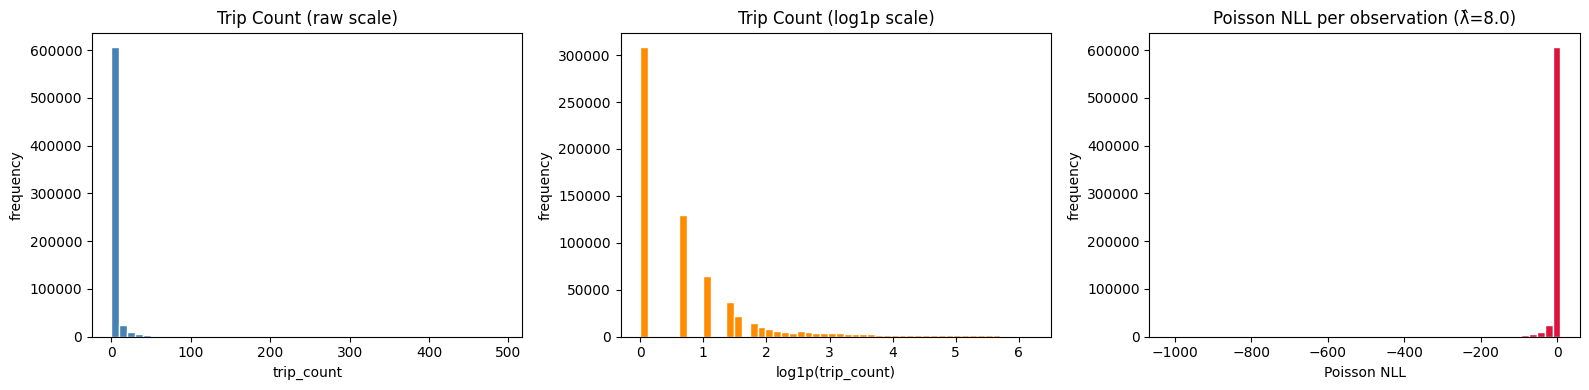

In [148]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (λ̂={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()